# Sensor Noise Simulation

Load a diffuse-map HDF5 from `general_positive`, inspect basic stats, and display it.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
shape: (50, 50)
dtype: float32
valid pixel count: 2500
valid min: 0.2999919652938843
valid max: 0.5
valid mean: 0.4258423447608948


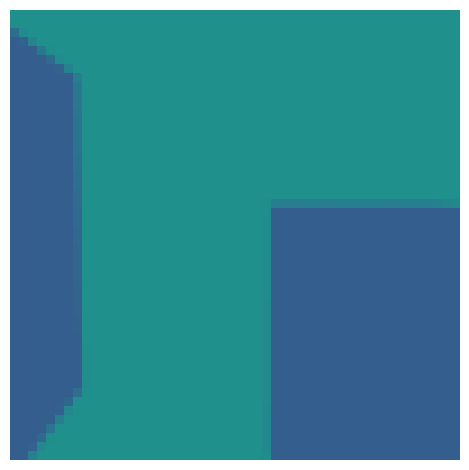

In [3]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from pythonLib.diffuseMapLib import read_diffuseMap_file, display_diffuseMap

# Preferred explicit file path
diffuse_map_file = Path('../general_positive/diffuseMap/positive_diffuse_2.h5')

diffuse_map = read_diffuseMap_file(str(diffuse_map_file))
print('shape:', diffuse_map.shape)
print('dtype:', diffuse_map.dtype)

valid = diffuse_map[diffuse_map >= 0]
print('valid pixel count:', valid.size)
if valid.size > 0:
    print('valid min:', float(valid.min()))
    print('valid max:', float(valid.max()))
    print('valid mean:', float(valid.mean()))

display_diffuseMap(diffuse_map, value_range=(0.0, 1.0), title='General Positive Diffuse Map')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


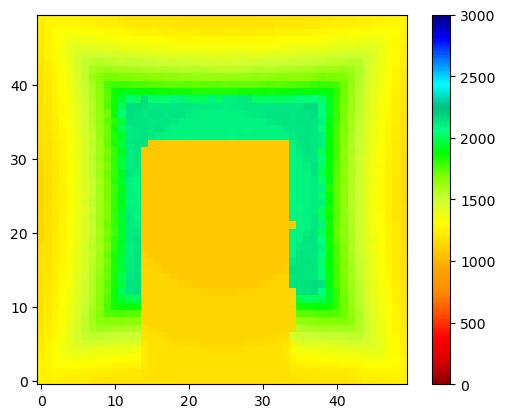

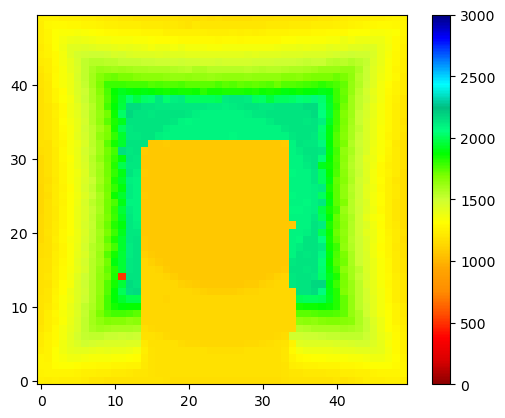

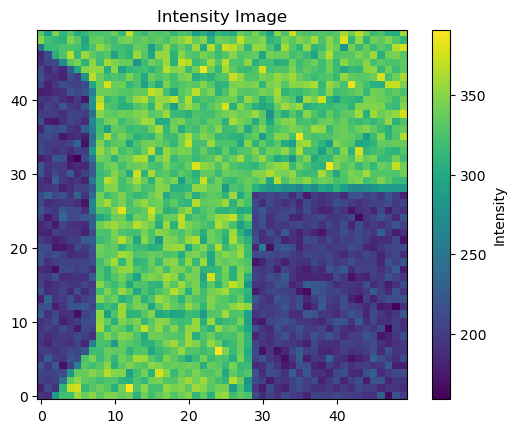

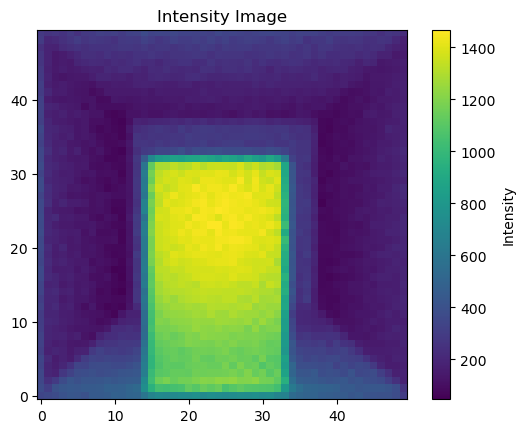

DNL and ANL(INL) for selected pixels: [(10, 10), (20, 20), (30, 30), (40, 40)]


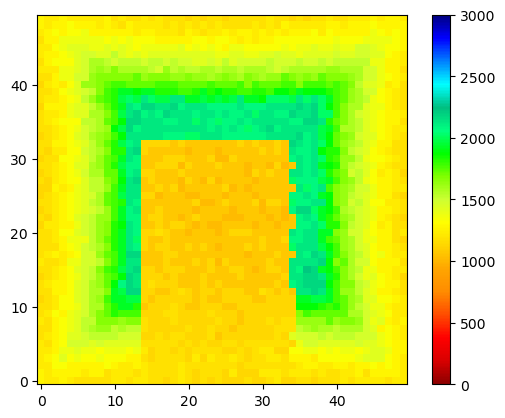

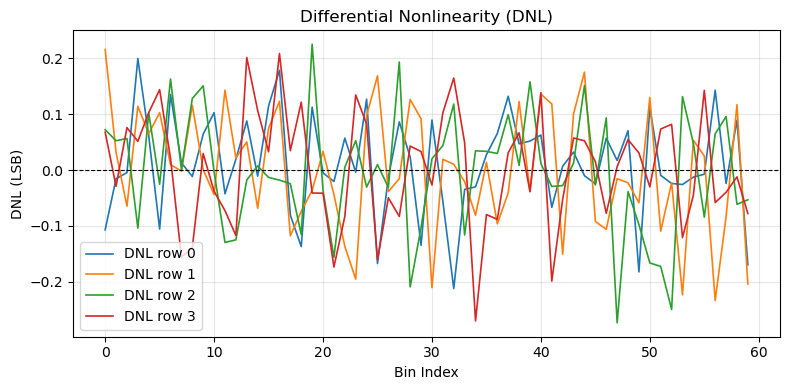

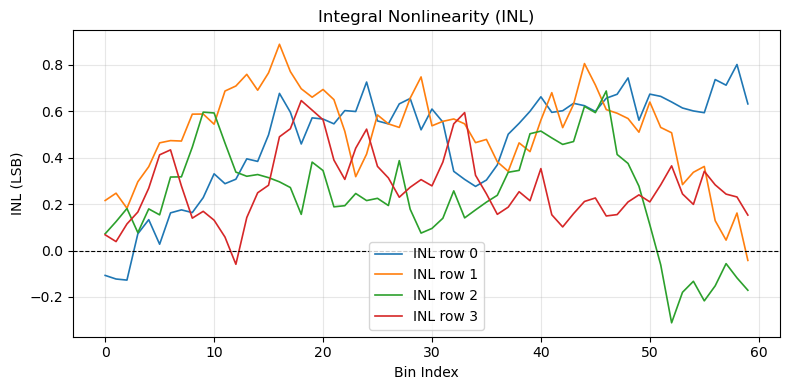

0.5439393132683771


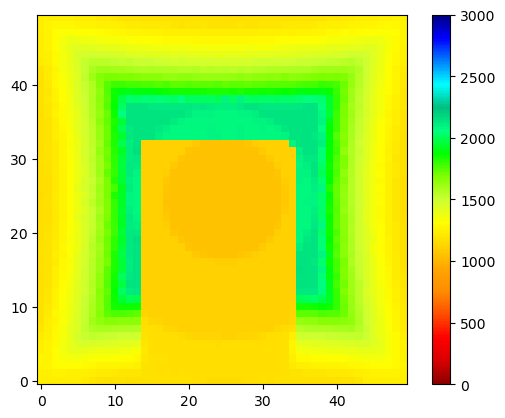

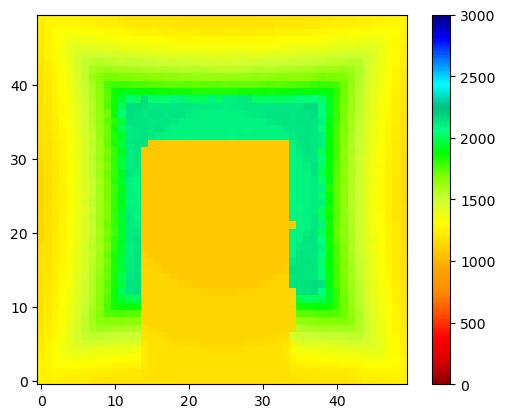

In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pythonLib.formImageLib import *
from pythonLib.dnlNoiseLib import *
from pythonLib.diffuseMapLib import read_diffuseMap_file
from pythonLib.ambientNoiseLib import *
from pythonLib.postProcessLib import *
pixelized_time_stamp_file = Path('../general_negative/pixelizedData/negative_pixelized_1111.h5')
myRange = [0,3000]

pixels, image_width, image_heigh = decode_file(pixelized_time_stamp_file)
image, illegal_photon, stamped_histogram, stamped_collosion = form_histogram_image(
    pixels,
    image_width,
    image_heigh,
    bin_number=60,
    range_distance=myRange,
    peak_func=peak_found_center_of_mass,
)

diffuse_map_file = Path('../general_positive/diffuseMap/positive_diffuse_2.h5')
diffuse_map = read_diffuseMap_file(str(diffuse_map_file))

display_image(image, distance_range=myRange)



# display_image(dnl_image, distance_range=myRange)

# Plot DNL/ANL for selected pixels


ambient_noise = generate_ambient_noise(
    dnl_matrix=None,
    histogram_matrixc=stamped_histogram,
    diffuse_map=diffuse_map,
    noise_factor=60,
    seed=1,
)

# Add ambient noise to histogram and reconstruct a depth image from noisy histogram.
# noisy_histogram = stamped_histogram + ambient_noise
noisy_histogram = ambient_noise + stamped_histogram

bin_number = noisy_histogram.shape[2]
bin_width = (myRange[1] - myRange[0]) / bin_number
noisy_depth_image = from_distance_from_histogram(range_max=myRange[1],range_min=myRange[0], histogram=noisy_histogram,peak_find=peak_found_center_of_mass) 

noisy_intensity = form_intensity_from_histogram(ambient_noise)
sensor_intensity = form_intensity_from_histogram(stamped_histogram)
# Existing helper visualization
display_image(noisy_depth_image, distance_range=myRange)
display_intensity(noisy_intensity)
display_intensity(sensor_intensity)

random_dnl = generate_dnl_matrix(
    image_width=image_width,
    image_height=image_heigh,
    dnl_value=0.1,
    seed=32,
    bin_number=60,
)
dnl_image, _, dnl_histogram, _ = form_histogram_image(
    pixels,
    image_width,
    image_heigh,
    bin_number=60,
    range_distance=myRange,
    peak_func=peak_found_center_of_mass,
    dnl_matrix=random_dnl,
)

dnl_depth_image = from_distance_from_histogram(range_max=myRange[1],range_min=myRange[0],histogram=dnl_histogram)
selected_pixels = [(10, 10), (20, 20), (30, 30), (40, 40)]
selected_pixels = [
    (int(np.clip(x, 0, image_width - 1)), int(np.clip(y, 0, image_heigh - 1)))
    for x, y in selected_pixels
]
dnl_rows = [random_dnl[x, y, :] for x, y in selected_pixels]
print(f'DNL and ANL(INL) for selected pixels: {selected_pixels}')
display_image(dnl_depth_image,distance_range=myRange)
displayDNL(dnl_rows)
displayINL(dnl_rows)

dead_time_pixeles,discard_count,accept_count = dead_time_simulation(simulated_photon=pixels,
pluse_train_num= 2000)
                                 
                                                                    
print(discard_count/(discard_count+accept_count))
dead_time_image, illegal_photon, dead_time_stamped_histogram, dead_time_stamped_collosion = form_histogram_image(    
        dead_time_pixeles,
        image_width,
        image_heigh,
        bin_number=50,
        range_distance=myRange,
        peak_func=peak_found_center_of_mass,
    )

display_image(dead_time_image,distance_range=myRange)
display_image(image,distance_range=myRange)